In [1]:
# ==========================================
# Step 1: Import Required Libraries
# ==========================================

# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Save Model
import joblib

In [2]:
# ==========================================
# Step 2: Upload Dataset
# ==========================================

from google.colab import files

uploaded = files.upload()


Saving diabetes.csv to diabetes.csv


In [3]:
# ==========================================
# Load Dataset
# ==========================================

import pandas as pd

df = pd.read_csv("diabetes.csv")

print("Dataset Loaded Successfully!")

df.head()

Dataset Loaded Successfully!


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# ==========================================
# Step 3.1: Dataset Shape
# ==========================================

print("Dataset Shape:", df.shape)

Dataset Shape: (768, 9)


In [5]:
# ==========================================
# Step 3.2: Dataset Information
# ==========================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
# ==========================================
# Step 3.3: Statistical Summary
# ==========================================

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
# ==========================================
# Step 3.4: Missing Values
# ==========================================

df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
print(df.shape)

df.info()

df.describe()

df.isnull().sum()

(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [9]:
# ==========================================
# Check Zero Values
# ==========================================

columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in columns:
    print(f"{col}: {(df[col] == 0).sum()} zero values")

Glucose: 5 zero values
BloodPressure: 35 zero values
SkinThickness: 227 zero values
Insulin: 374 zero values
BMI: 11 zero values


In [10]:
# ==========================================
# Replace 0 with NaN
# ==========================================

import numpy as np

columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[columns] = df[columns].replace(0, np.nan)

df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [11]:
# ==========================================
# Fill Missing Values
# ==========================================

for col in columns:
    df[col] = df[col].fillna(df[col].median())

print("Missing values handled successfully!")

df.isnull().sum()

Missing values handled successfully!


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [12]:
# ==========================================
# Verify Missing Values
# ==========================================

df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


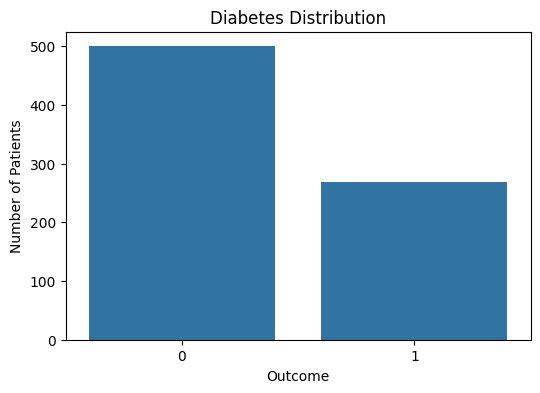

In [13]:
# ==========================================
# Diabetes Distribution
# ==========================================

plt.figure(figsize=(6,4))

sns.countplot(x="Outcome", data=df)

plt.title("Diabetes Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.show()

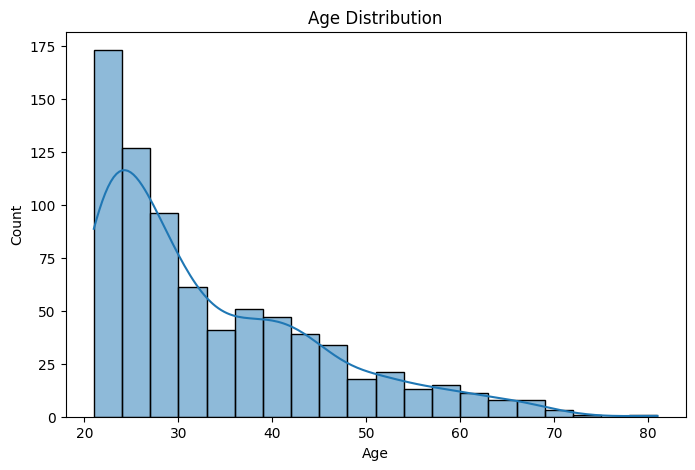

In [14]:
# ==========================================
# Age Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")

plt.show()

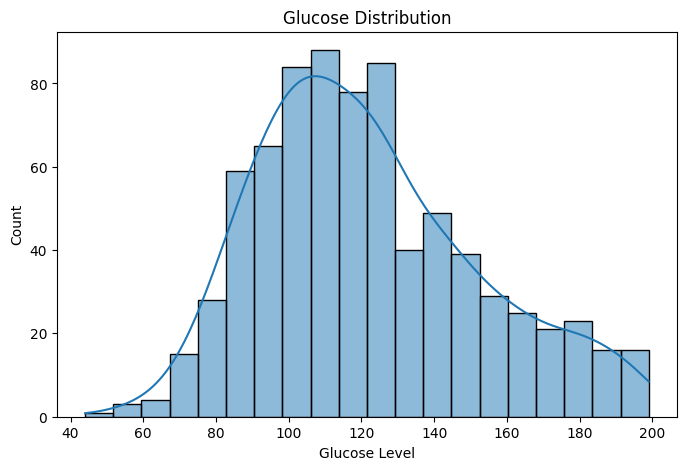

In [15]:
# ==========================================
# Glucose Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(df["Glucose"], bins=20, kde=True)

plt.title("Glucose Distribution")
plt.xlabel("Glucose Level")

plt.show()

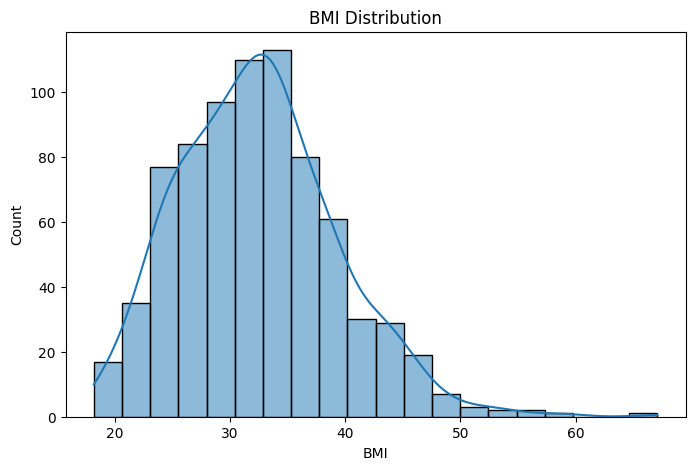

In [16]:
# ==========================================
# BMI Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(df["BMI"], bins=20, kde=True)

plt.title("BMI Distribution")
plt.xlabel("BMI")

plt.show()

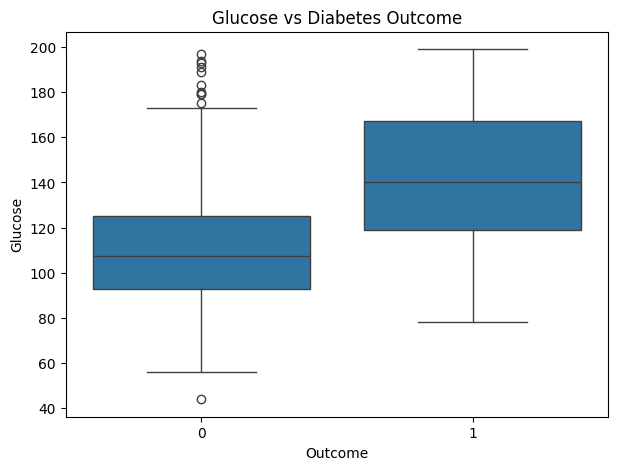

In [17]:
# ==========================================
# Glucose by Diabetes Outcome
# ==========================================

plt.figure(figsize=(7,5))

sns.boxplot(x="Outcome", y="Glucose", data=df)

plt.title("Glucose vs Diabetes Outcome")

plt.show()

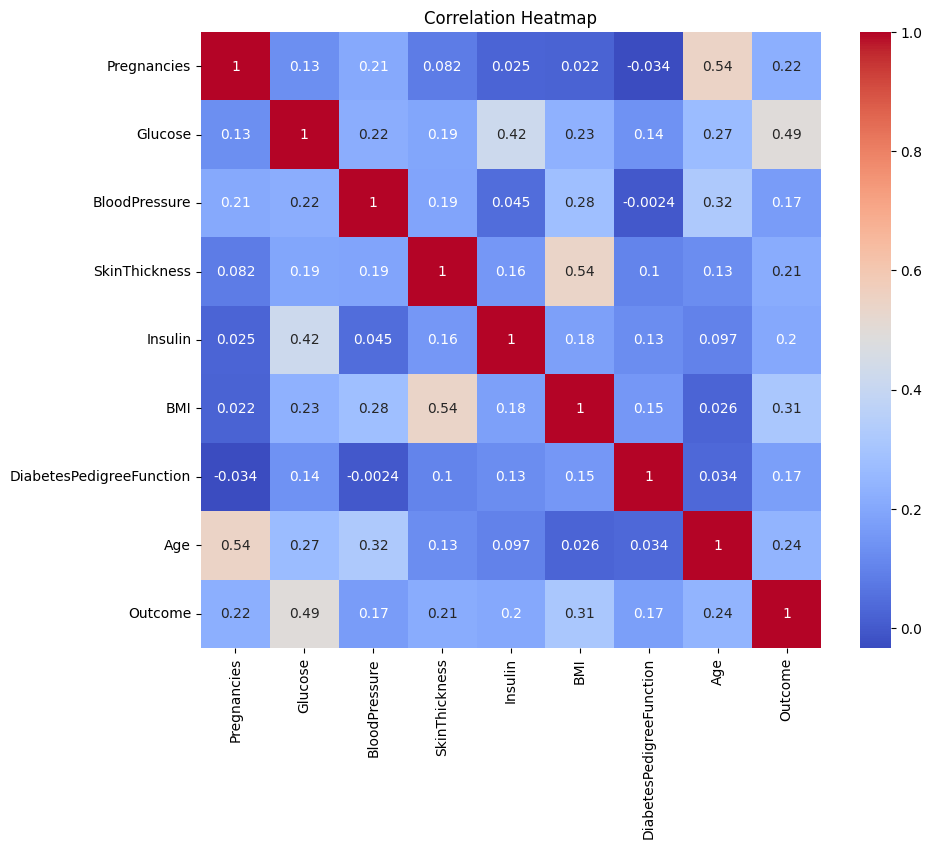

In [18]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [19]:
# ==========================================
# Step 6.1 - Feature Selection
# ==========================================

# Features
X = df.drop("Outcome", axis=1)

# Target
y = df["Outcome"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (768, 8)
Target Shape: (768,)


In [20]:
# ==========================================
# Step 6.2 - Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (614, 8)
Testing Shape: (154, 8)


In [21]:
# ==========================================
# Step 6.3 - Feature Scaling
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed!")

Feature Scaling Completed!


In [22]:
# ==========================================
# Step 7.1 - Create Logistic Regression Model
# ==========================================

model = LogisticRegression(random_state=42)

print(model)


LogisticRegression(random_state=42)


In [23]:
# ==========================================
# Step 7.2 - Train the Model
# ==========================================

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [24]:
# ==========================================
# Step 7.3 - Make Predictions
# ==========================================

y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[0 0 0 0 0 0 0 0 1 1]


In [25]:
# ==========================================
# Step 7.4 - Accuracy Score
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.75


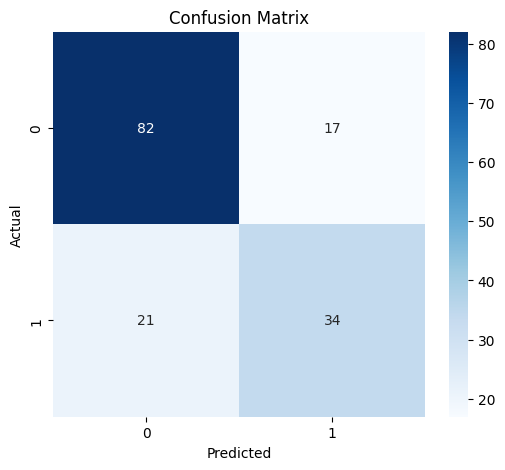

In [26]:
# ==========================================
# Step 7.5 - Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [27]:
# ==========================================
# Step 7.6 - Classification Report
# ==========================================

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



In [28]:
# ==========================================
# Step 8: Save Trained Model
# ==========================================

import joblib

# Save the trained model
joblib.dump(model, "Diabetes_Model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [29]:
from google.colab import files

files.download("Diabetes_Model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>